## Euler's Method: Challenge 15
### This script loops step size to go from .01 to 1, steps of .05, prints the error (current run vs first run) for each point and the total accumulated error for each run. Then, plots each step-size run on a graph and analyzes the results. 


In [14]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np

# Define parameters
x_start, x_end = 0, 2

# Function
def f(x, y):
    return -2 * y

# Step sizes
step_sizes = np.arange(0.01, 1.01, 0.05)

# Store first run
first_run_y = None
first_run_x = None

# Store results for plotting later
all_x = []
all_y = []
all_h = []

for h in step_sizes:

    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    y_values[0] = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    # Save for plotting later
    all_x.append(x_values)
    all_y.append(y_values)
    all_h.append(h)

    # Save first run
    if first_run_y is None:
        first_run_y = y_values
        first_run_x = x_values

    # Interpolate for comparison
    y_interp = np.interp(first_run_x, x_values, y_values)

    error = np.abs(y_interp - first_run_y)
    total_error = np.sum(error)
    # Interpolate current run onto first run grid

    print(f"\nStep size h = {round(h, 3)}")

    print("Error at each point (current run vs first run):")
    print(error)

    print("Total accumulated error:", total_error)
    print("-" * 50)


Step size h = 0.01
Error at each point (current run vs first run):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Total accumulated error: 0.0
--------------------------------------------------

Step size h = 0.06
Error at each point (current run vs first run):
[0.         0.0002     0.         0.000592   0.00156816 0.0029208
 0.00464238 0.00449353 0.00455502 0.00496376 0.00571281 0.00679535
 0.00820472 0.00809695 0.00804962 0.00

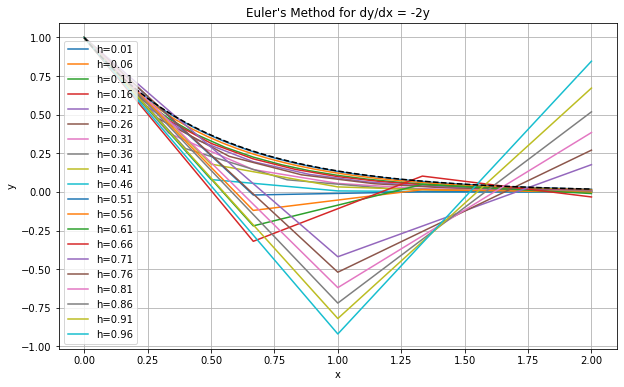

In [15]:
# Plot all runs
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

for i in range(len(all_h)):
    plt.plot(all_x[i], all_y[i], label=f"h={round(all_h[i],2)}")
    
plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method for dy/dx = -2y")
plt.legend()

# Reference curve (black dashed line) - asked ChatGPT how to add this 
x_true = np.linspace(0, 2, 200)
y_true = np.exp(-2 * x_true)
plt.plot(x_true, y_true, 'k--')

plt.grid()
plt.show()

### The figure shows that as the step size (h) increases, Euler’s method becomes less accurate as the solutions deviate more from the reference curve (black dashed line). This demonstrates that numerical error grows with larger step sizes, confirming that smaller h produces more reliable approximations. We also see this pattern literally in the printed errors above, as they start at 0 and end at 86. 